# Seção 4. Estudo de Caso: Catálogo DES DR2

Autor: Heleno Campos

Ultima atualização: 27/05/2026

**Banco de dados:** `dados/processed/course_database.db`  
**Schema:**
- `objects(id, ra, dec, color_gr, color_ri, extended_class)`
- `object_bands(band_id, object_id, band, num_obs, mag_auto, magerr_auto)`

**Relação:** `objects.id` = `object_bands.object_id` (1:N) — cada objeto tem uma linha por banda (g, r, i, z, y)

**Pipeline:**
1. Explorar o schema do banco
2. Selecionar galáxias com cobertura multi-banda
3. Gerar diagrama cor-magnitude (CMD)
4. Rankear e exportar catálogo de alvos

---

## 1. Importações e conexão

In [25]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterMathtext

DB = '../dados/processed/course_database.db'

---
## 2. Exploração do schema

In [26]:
with sqlite3.connect(DB) as conn:
    cur = conn.cursor()

    # Tabelas disponíveis
    cur.execute("SELECT name FROM sqlite_master WHERE type='table' AND name != 'sqlite_sequence'")
    tabelas = [r[0] for r in cur.fetchall()]
    print('Tabelas:', tabelas)

    # Contagem de linhas
    for t in tabelas:
        cur.execute(f'SELECT COUNT(*) FROM {t}')
        print(f'  {t}: {cur.fetchone()[0]:,} linhas')

Tabelas: ['objects', 'object_bands']
  objects: 150,000 linhas
  object_bands: 674,451 linhas


In [27]:
# Primeiras linhas de cada tabela
with sqlite3.connect(DB) as conn:
    print('=== objects ===')
    display(pd.read_sql_query('SELECT * FROM objects LIMIT 3', conn))

    print('=== object_bands ===')
    display(pd.read_sql_query('SELECT * FROM object_bands LIMIT 6', conn))

=== objects ===


,id,ra,dec,color_gr,color_ri,extended_class
0,1239792751,32.014709,-23.914383,0.555288,0.276230,3.0
1,1239792872,32.008781,-23.904523,1.059340,0.351667,0.0
2,1239792908,32.016142,-23.912456,0.950520,0.742758,3.0


=== object_bands ===


,band_id,object_id,band,num_obs,mag_auto,magerr_auto
0,1,1275048968,g,5,22.670219,0.055466
1,2,1275048968,r,5,21.095091,0.017273
2,3,1275048968,i,5,20.601419,0.019469
3,4,1275048968,z,5,20.330437,0.031835
4,5,1275048968,y,4,20.328272,0.115495
5,6,1275048999,g,2,23.580633,0.126921


In [28]:
# Distribuição de extended_class (tipo de objeto)
with sqlite3.connect(DB) as conn:
    df_cls = pd.read_sql_query("""
        SELECT extended_class, COUNT(*) AS n
        FROM objects GROUP BY extended_class ORDER BY n DESC
    """, conn)

print('Valores de extended_class:')
print('  3.0 = galáxia, 0.0 = estrela, outros = incertos')
print(df_cls.to_string(index=False))

Valores de extended_class:
  3.0 = galáxia, 0.0 = estrela, outros = incertos
 extended_class      n
            3.0 120962
            0.0  16198
            2.0  10265
            1.0   2573
           -9.0      2


In [29]:
# Bandas disponíveis em object_bands
with sqlite3.connect(DB) as conn:
    df_bands_info = pd.read_sql_query("""
        SELECT band, COUNT(*) AS n, ROUND(AVG(mag_auto), 2) AS mag_media
        FROM object_bands
        GROUP BY band
        ORDER BY band
    """, conn)
print(df_bands_info.to_string(index=False))

band      n  mag_media
   g 150000      23.09
   i 150000      21.73
   r 150000      22.22
   y  74451      20.44
   z 150000      21.45


---
## 3. Etapa 1: Seleção de galáxias

Filtros:
- `extended_class = 3` -> galáxias
- `mag_auto < 23.0` na banda `i` -> limite de brilho
- cobertura em pelo menos 3 bandas distintas (via JOIN com `object_bands`)

In [30]:
SQL_SELECAO = """
    WITH cobertura AS (
        SELECT object_id
        FROM   object_bands
        GROUP  BY object_id
        HAVING COUNT(DISTINCT band) >= 3
    )
    SELECT o.id,
           o.ra,
           o.dec,
           ob_i.mag_auto     AS mag_auto_i,
           ob_i.magerr_auto  AS magerr_auto_i,
           o.color_gr
    FROM   objects o
    JOIN   cobertura c   ON o.id = c.object_id
    JOIN   object_bands ob_i
                         ON o.id = ob_i.object_id
                        
    WHERE  ob_i.mag_auto     <  23.0
      AND  o.extended_class   =  3
      AND ob_i.band = 'i'
"""

with sqlite3.connect(DB) as conn:
    df = pd.read_sql_query(SQL_SELECAO, conn)

print(f'Galáxias selecionadas: {len(df):,}')
df.describe()

Galáxias selecionadas: 107,048


,id,ra,dec,mag_auto_i,magerr_auto_i,color_gr
count,1.070480e+05,107048.000000,107048.000000,107048.000000,107048.000000,107048.000000
mean,1.251172e+09,33.120491,-24.226904,21.618312,0.053143,0.915032
std,6.497572e+06,0.825961,0.647878,1.103713,0.032928,0.430417
min,1.239793e+09,32.005405,-25.493718,13.716060,0.000206,-0.706304
25%,1.245964e+09,32.499728,-24.751838,21.052718,0.025856,0.614578
50%,1.251456e+09,32.985660,-24.292820,21.875819,0.048963,0.857133
75%,1.257327e+09,33.606783,-23.790205,22.453775,0.076409,1.154082
max,1.283065e+09,36.869860,-22.696192,22.999977,0.242523,5.200392


---
## 4. Diagnóstico com EXPLAIN QUERY PLAN

In [31]:
with sqlite3.connect(DB) as conn:
    cur = conn.cursor()
    cur.execute('EXPLAIN QUERY PLAN ' + SQL_SELECAO)
    for row in cur.fetchall():
        print(row)

(2, 0, 0, 'CO-ROUTINE cobertura')
(9, 2, 223, 'SCAN object_bands USING INDEX idx_object_bands_object_id')
(41, 2, 0, 'USE TEMP B-TREE FOR count(DISTINCT)')
(48, 0, 62, 'SEARCH ob_i USING INDEX idx_object_bands_band (band=?)')
(56, 0, 45, 'SEARCH o USING INTEGER PRIMARY KEY (rowid=?)')
(64, 0, 0, 'BLOOM FILTER ON c (object_id=?)')
(75, 0, 47, 'SEARCH c USING AUTOMATIC COVERING INDEX (object_id=?)')


---
## 5. Etapa 2: Diagrama Cor-Magnitude (CMD)

- **Eixo X:** magnitude $i$ (brilho; eixo invertido: menor = mais brilhante)
- **Eixo Y:** cor $g-r$ (temperatura: galáxias azuis vs vermelhas)

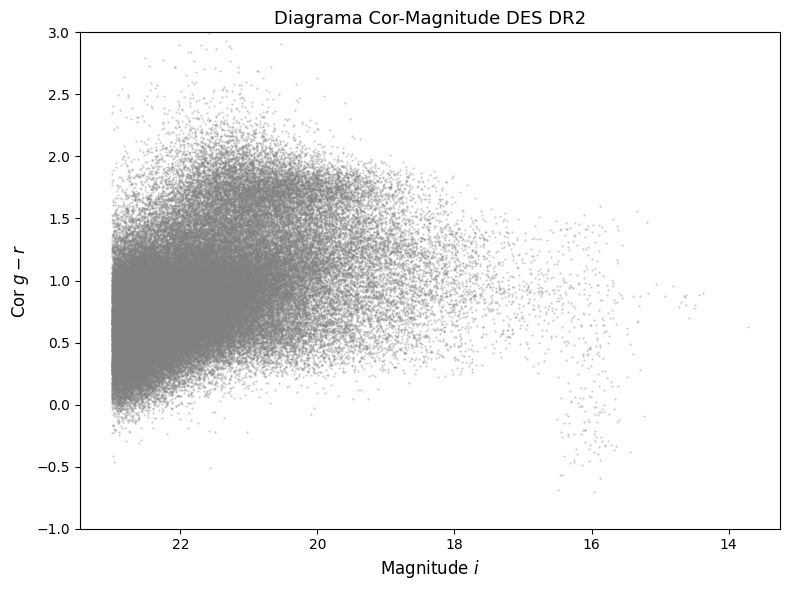

107,048 galáxias plotadas


In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    df['mag_auto_i'],
    df['color_gr'],
    s=0.5, alpha=0.3,
    c='gray',
    rasterized=True
)

ax.set_xlabel('Magnitude $i$', fontsize=12)
ax.set_ylabel('Cor $g-r$', fontsize=12)
ax.set_title('Diagrama Cor-Magnitude DES DR2', fontsize=13)
ax.invert_xaxis()
ax.set_ylim(-1,3)

plt.tight_layout()
plt.savefig('../dados/cmd_des_dr2.png', dpi=150)
plt.show()
print(f'{len(df):,} galáxias plotadas')

Cada ponto representa uma galaxia. O eixo horizontal mostra o brilho: quanto mais a direita, mais brilhante a galaxia (magnitude maior = mais fraca). O corte visivel na magnitude 23 é o nosso filtro da query. O eixo vertical mostra a cor g-r: valores menores indicam galaxias mais azuis (com formacao de estrelas ativa), valores maiores indicam galaxias mais vermelhas (mais antigas e passivas).

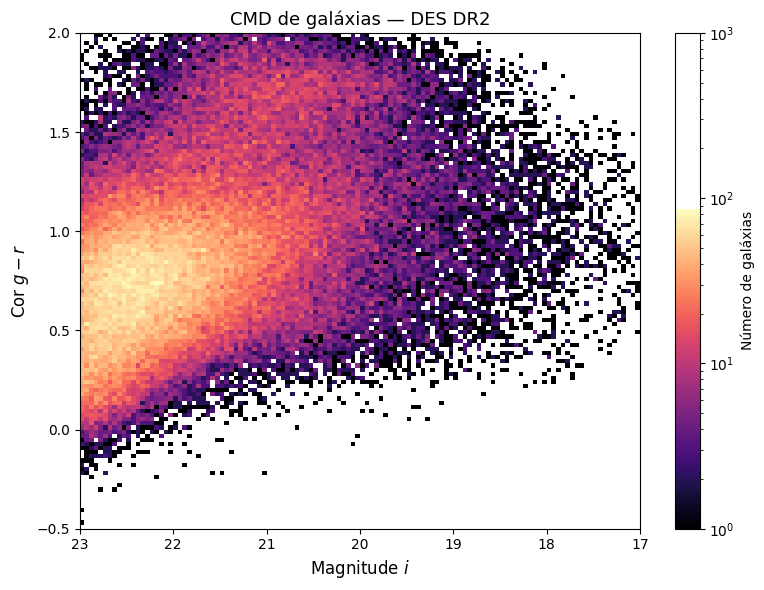

In [33]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterMathtext

fig, ax = plt.subplots(figsize=(8, 6))

h = ax.hist2d(
    df['mag_auto_i'],
    df['color_gr'],
    bins=(120, 120),
    range=[[17, 23], [-0.5, 2.0]],
    cmap='magma',
    norm=LogNorm(vmin=1)
)

cbar = plt.colorbar(h[3], ax=ax)

cbar.locator = LogLocator(base=10)
cbar.formatter = LogFormatterMathtext(base=10)
cbar.set_ticks([1, 10, 100, 1000])
cbar.update_ticks()

cbar.set_label('Número de galáxias')

ax.set_xlim(23, 17)

ax.set_xlabel(r'Magnitude $i$', fontsize=12)
ax.set_ylabel(r'Cor $g-r$', fontsize=12)
ax.set_title('CMD de galáxias — DES DR2', fontsize=13)

plt.tight_layout()
plt.savefig('../dados/cmd_des_dr2_densidade.png', dpi=150)
plt.show()

O mesmo diagrama anterior, agora com as galaxias agrupadas em celulas coloridas pela quantidade de objetos, usando uma escala logaritmica de cor. Branco/laranja indica regioes de altissima densidade (milhares de galaxias por celula), roxo escuro indica regioes esparsas.

O pico de densidade aparece em torno de magnitude i ~ 22-23 e cor g-r ~ 0.7-1.0: a maioria das galaxias selecionadas e moderadamente vermelha e relativamente fraca, consistente com galaxias tipicas a distancias intermediarias. A queda em direcao a magnitudes brilhantes (esquerda do grafico) reflete que galaxias proximas e brilhantes sao muito mais raras do que galaxias distantes e fracas.

---
## 6. Etapa 3: Ranking e exportação do catálogo

In [34]:
# Ranking global por brilho (menor magnitude = mais brilhante)
df['rank'] = df['mag_auto_i'].rank(method='min')

top500 = df[df['rank'] <= 500].copy().sort_values('mag_auto_i')

print(f'Galáxias selecionadas: {len(top500)}')
print(f'Magnitude mínima: {top500["mag_auto_i"].min():.3f}')
print(f'Magnitude máxima: {top500["mag_auto_i"].max():.3f}')
top500[['id', 'ra', 'dec', 'mag_auto_i', 'color_gr']].head(10)

Galáxias selecionadas: 500
Magnitude mínima: 13.716
Magnitude máxima: 17.214


,id,ra,dec,mag_auto_i,color_gr
46244,1258147693,33.836541,-24.600267,13.716060,0.629525
46852,1258145131,33.795767,-24.576800,14.382258,0.895601
75740,1246518041,32.346892,-23.879149,14.427939,0.886730
42051,1257342150,33.731604,-24.854758,14.489409,0.800257
11960,1251610753,32.929853,-25.217961,14.501376,0.779480
68877,1258099052,34.060818,-24.045626,14.573995,0.695467
69672,1258764769,33.925037,-23.835884,14.616016,0.805202
70475,1258090119,34.240015,-23.972257,14.624144,0.879924
77913,1246500237,32.253223,-23.672964,14.644908,0.863376
89241,1240997197,32.168060,-23.534592,14.659433,0.873131


In [35]:
# Exportar catálogo de alvos
colunas = ['id', 'ra', 'dec', 'mag_auto_i', 'color_gr']
top500[colunas].to_csv('../dados/alvos_des_dr2.csv', index=False)
print('Exportado: dados/alvos_des_dr2.csv')

Exportado: dados/alvos_des_dr2.csv


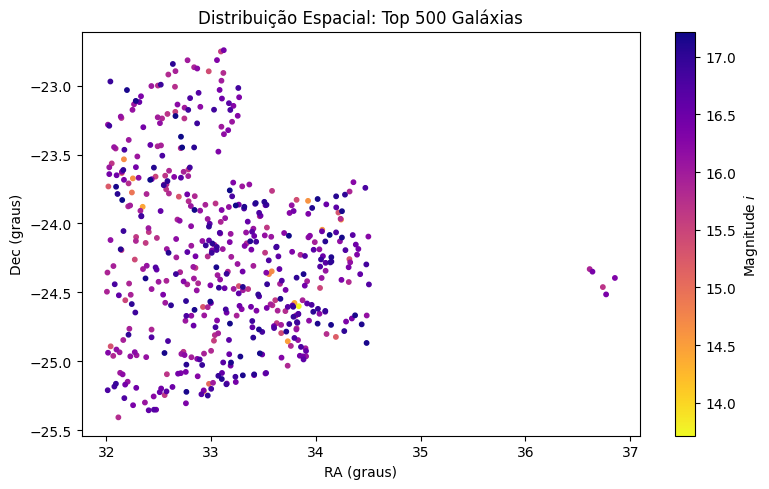

In [36]:
# Distribuição espacial dos alvos
fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(
    top500['ra'], top500['dec'],
    s=10, c=top500['mag_auto_i'],
    cmap='plasma_r'
)
plt.colorbar(sc, ax=ax, label='Magnitude $i$')
ax.set_xlabel('RA (graus)')
ax.set_ylabel('Dec (graus)')
ax.set_title('Distribuição Espacial: Top 500 Galáxias')
plt.tight_layout()
plt.savefig('../dados/mapa_alvos.png', dpi=150)
plt.show()

Cada ponto mostra a posição no céu de uma das 500 galáxias mais brilhantes selecionadas, em coordenadas de Right Ascension (RA) e Declinação (Dec). A cor indica o brilho: tons amarelos e laranja são as galáxias mais brilhantes, tons escuros as mais fracas dentro do top 500. 

Os dois grupos separados no gráfico refletem a geometria do levantamento DES. O survey não cobre o céu de forma contínua, mas em campos específicos. O grupo menor isolado (RA ~ 32°, Dec ~ −28°) é um campo separado do DES DR2.